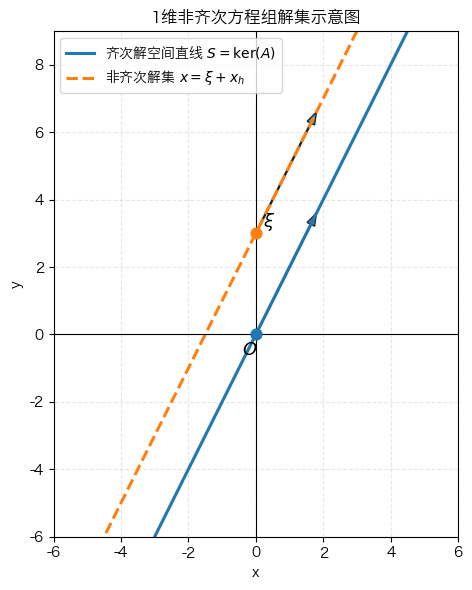

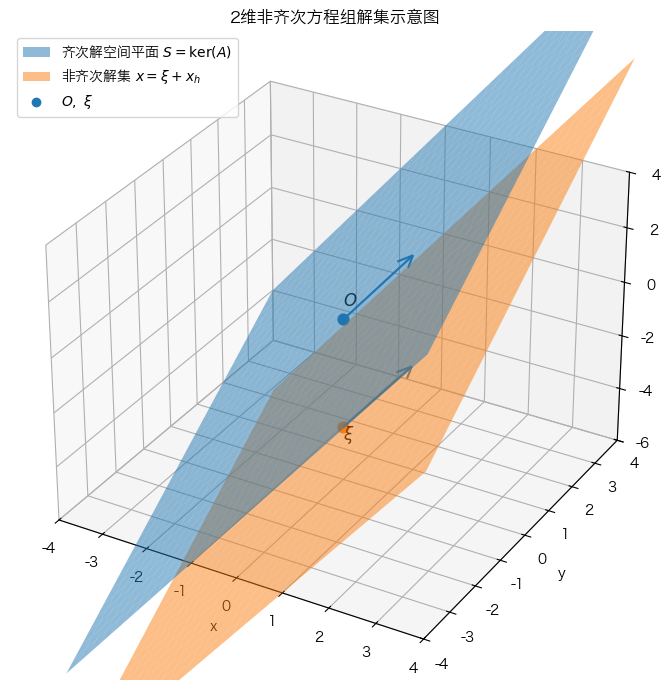

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # 仅为触发 3D 支持
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

# 如果你本机有中文字体，可以这样启用中文显示
plt.rcParams['font.sans-serif'] = ['PingFang SC', 'Hiragino Sans GB', 'Heiti SC', 'Songti SC']
plt.rcParams['axes.unicode_minus'] = False


def plot_1d_example():
    """1 维：齐次解空间是一条直线，非齐次解集是它的平移直线"""
    x = np.linspace(-6, 6, 200)

    # 齐次解空间：y = 2x
    y_h = 2 * x
    # 非齐次解集：y = 2x + 3
    y_nh = 2 * x + 3

    origin = np.array([0.0, 0.0])   # 原点 O
    xi = np.array([0.0, 3.0])       # 特解 ξ
    direction = np.array([1.0, 2.0])  # 齐次方向向量（与直线同方向）

    fig, ax = plt.subplots(figsize=(7, 6))
    ax.set_title("1维非齐次方程组解集示意图")

    # 直线
    ax.plot(x, y_h, linewidth=2.2, label=r'齐次解空间直线 $S=\ker(A)$')
    ax.plot(x, y_nh, linewidth=2.2, linestyle='--',
            label=r'非齐次解集 $x=\xi+x_h$')

    # 点
    ax.scatter(*origin, s=60, zorder=5)
    ax.scatter(*xi, s=60, zorder=5)
    ax.text(origin[0] - 0.4, origin[1] - 0.6, r'$O$', fontsize=13)
    ax.text(xi[0] + 0.2, xi[1] + 0.2, r'$\xi$', fontsize=13)

    # 方向箭头：同一个方向，从 O 和 ξ 分别出发，体现“平移”
    scale = 1.8
    ax.arrow(origin[0], origin[1],
             scale * direction[0], scale * direction[1],
             width=0.03, head_width=0.25, length_includes_head=True,
             alpha=0.8)
    ax.arrow(xi[0], xi[1],
             scale * direction[0], scale * direction[1],
             width=0.03, head_width=0.25, length_includes_head=True,
             alpha=0.8)

    # 坐标轴与网格
    ax.axhline(0, color='black', linewidth=0.8)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlim(-6, 6)
    ax.set_ylim(-6, 9)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_aspect('equal', 'box')
    ax.grid(alpha=0.3, linestyle='--')
    ax.legend(loc='upper left')

    plt.tight_layout()
    plt.show()


def plot_2d_example():
    """2 维：齐次解空间是过原点的平面，非齐次解集是平移平面"""
    # 平面：
    # 齐次：2x + y - z = 0  -> z = 2x + y
    # 非齐次：2x + y - z = 4 -> z = 2x + y - 4
    x = np.linspace(-4, 4, 30)
    y = np.linspace(-4, 4, 30)
    X, Y = np.meshgrid(x, y)

    Z_h = 2 * X + Y
    Z_nh = 2 * X + Y - 4

    origin = np.array([0.0, 0.0, 0.0])   # 原点 O
    xi = np.array([0.0, 0.0, -4.0])      # 特解 ξ（在平移后的平面上）
    direction = np.array([1.0, 0.0, 2.0])  # 在平面上的方向向量（满足 2x + y - z = 0）

    fig = plt.figure(figsize=(9, 7))
    ax = fig.add_subplot(111, projection='3d')
    ax.set_title("2维非齐次方程组解集示意图")

    # 画两个平面
    plane_h = ax.plot_surface(X, Y, Z_h, alpha=0.5)
    plane_nh = ax.plot_surface(X, Y, Z_nh, alpha=0.5)

    # 点
    ax.scatter(*origin, s=60)
    ax.scatter(*xi, s=60)
    ax.text(origin[0], origin[1], origin[2] + 0.5, r'$O$', fontsize=12)
    ax.text(xi[0], xi[1], xi[2] - 0.5, r'$\xi$', fontsize=12)

    # 齐次方向箭头：同一个方向，从 O 和 ξ 出发
    scale = 1.5
    ax.quiver(origin[0], origin[1], origin[2],
              scale * direction[0], scale * direction[1], scale * direction[2],
              arrow_length_ratio=0.15)
    ax.quiver(xi[0], xi[1], xi[2],
              scale * direction[0], scale * direction[1], scale * direction[2],
              arrow_length_ratio=0.15)

    # 坐标轴范围
    ax.set_xlim(-4, 4)
    ax.set_ylim(-4, 4)
    ax.set_zlim(-6, 4)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_zlabel('z')

    # 3D 里 plot_surface 不支持 label，用代理对象做 legend
    legend_elements = [
        Patch(facecolor=plane_h.get_facecolor()[0],
              label=r'齐次解空间平面 $S=\ker(A)$'),
        Patch(facecolor=plane_nh.get_facecolor()[0],
              label=r'非齐次解集 $x=\xi+x_h$'),
        Line2D([0], [0], marker='o', linestyle='None',
               label=r'$O,\ \xi$')
    ]
    ax.legend(handles=legend_elements, loc='upper left')

    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    # 依次画出 1D（2D 图）和 2D（3D 图）的示意
    plot_1d_example()
    plot_2d_example()
